# Bonus Task · QLoRA Fine-tuning of Llama-3-8B-Instruct

**NALAPRO project · 20 Newsgroups · Master's NLP**

This notebook fine-tunes Llama-3-8B-Instruct on the 20-Newsgroups
classification task using **QLoRA**: a 4-bit-quantized base model + LoRA
adapters injected into every linear projection. We train ~1 % of the model's
parameters and compare against the zero-shot / few-shot baselines from
Task 4.

## What this notebook produces

1. **Trained QLoRA adapter** saved to `llama3-8b-20newsgroups-qlora/`
2. **Fine-tuned evaluation** on the same 300-doc test set Task 4 used
3. **Side-by-side comparison** table + bar chart vs Task 4 regimes
4. **Confusion matrix** for the fine-tuned model + side-by-side CM figure
5. All training metrics streamed to **Weights & Biases**

## Prerequisites

1. You have run `task4_llama3_zero_few_shot.ipynb` and have the file
   `task4_metrics.json` somewhere accessible (in this Colab session, or
   uploadable).
2. Fresh Colab session (recommended — old session may have GPU memory
   still pinned from Task 4).

## Wall-clock estimate (T4 GPU)

| Stage | Time |
|---|---|
| Setup + data + model load | ~10 min |
| QLoRA training (1 epoch, 900 docs) | ~35 min |
| Fine-tuned eval (300 docs) | ~10 min |
| Comparison + plots | ~1 min |
| **Total** | **~55 min** |

## 1 · Install

Same stack as Task 4, plus **TRL** (`SFTTrainer`) and **datasets** for the
training pipeline.

In [1]:
%%capture
!pip install -q -U bitsandbytes>=0.43
!pip install -q -U "transformers>=4.40,<4.46"
!pip install -q -U accelerate>=0.30
!pip install -q -U "peft>=0.10,<0.13"
!pip install -q -U trl                  # let it pick the latest; our code adapts to the API
!pip install -q -U datasets>=2.18
!pip install -q -U wandb>=0.17
!pip install -q -U scikit-learn matplotlib seaborn

## 2 · Imports, seed, GPU check

Also reports the installed TRL version — the bonus is sensitive to it
because the `SFTConfig` / `SFTTrainer` API changed twice in 2024-25.

In [2]:
import os, json, random, gc, warnings, inspect
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from datasets import Dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, pipeline,
    logging as hf_logging,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
import trl

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

os.environ["TOKENIZERS_PARALLELISM"] = "false"
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "GPU required."

print("Device :", torch.cuda.get_device_name(0))
print("VRAM   :", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Free   :", f"{torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
print("TRL version:", trl.__version__)

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
Free   : 42.0 GB
TRL version: 1.4.0


## 3 · Experiment configuration

Same data sizes as Task 4 (so the comparison is apples-to-apples). Plus the
QLoRA hyperparameters — see the explanation doc for the rationale on each.

In [3]:
# Data — same as Task 4 so comparisons are clean
N_TRAIN_PER_CLASS = 50      # → 1 000 training docs
N_TEST_PER_CLASS  = 15      # → 300 test docs
MAX_DOC_CHARS     = 500

# Model
BASE_MODEL    = "meta-llama/Meta-Llama-3-8B-Instruct"
OUTPUT_DIR    = "llama3-8b-20newsgroups-qlora"

# QLoRA hyperparameters
LORA_R        = 64          # adapter rank (QLoRA paper default for 7-13B)
LORA_ALPHA    = 16          # scaling: effective update = (alpha/r)·BA = 0.25·BA
LORA_DROPOUT  = 0.0         # no dropout needed at this scale
LEARNING_RATE = 2e-4        # LoRA tolerates higher LR than full FT
N_EPOCHS      = 1           # 1 epoch on 1 000 docs ≈ 35 min on T4
PER_DEVICE_BATCH = 1        # batch=1 × grad_accum=8 → effective batch 8
GRAD_ACCUM    = 8
MAX_LENGTH    = 768

# W&B
WANDB_PROJECT = "nalapro-task4-llama3"

# Path to the Task 4 metrics dump
TASK4_METRICS_PATH = Path("task4_metrics.json")

print("Config OK")

Config OK


## 4 · Hugging Face & Weights & Biases login

Same as Task 4. If you set up the secrets already in this session, you can
skip running this cell.

In [4]:
from huggingface_hub import login as hf_login

def _get_secret(name):
    v = os.environ.get(name)
    if v: return v
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        pass
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None

hf_tok = _get_secret("HF_TOKEN");  assert hf_tok, "HF_TOKEN missing"
hf_login(token=hf_tok); print("HF login OK")
wb_tok = _get_secret("WANDB_API_KEY"); assert wb_tok, "WANDB_API_KEY missing"
wandb.login(key=wb_tok); print("W&B login OK")

HF login OK


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: likhita-kolli (likhita-kolli-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login OK


## 5 · Data — same balanced subsample as Task 4

In [5]:
train_bunch = fetch_20newsgroups(subset="train",
                                 remove=("headers", "footers", "quotes"),
                                 shuffle=True, random_state=SEED)
test_bunch  = fetch_20newsgroups(subset="test",
                                 remove=("headers", "footers", "quotes"),
                                 shuffle=True, random_state=SEED)

LABELS      = list(train_bunch.target_names)
NUM_CLASSES = len(LABELS)
LABEL2ID    = {l: i for i, l in enumerate(LABELS)}
ID2LABEL    = {i: l for i, l in enumerate(LABELS)}

def subsample_balanced(texts, labels, n_per_class):
    kept_t, kept_y = [], []
    cnt = {i: 0 for i in range(NUM_CLASSES)}
    for t, y in zip(texts, labels):
        if not t or not t.strip(): continue
        if cnt[int(y)] < n_per_class:
            kept_t.append(t.strip()[:MAX_DOC_CHARS])
            kept_y.append(int(y))
            cnt[int(y)] += 1
        if all(c >= n_per_class for c in cnt.values()): break
    return kept_t, np.asarray(kept_y)

train_texts, train_labels = subsample_balanced(train_bunch.data,
                                                train_bunch.target,
                                                N_TRAIN_PER_CLASS)
test_texts,  test_labels  = subsample_balanced(test_bunch.data,
                                                test_bunch.target,
                                                N_TEST_PER_CLASS)
print(f"Train: {len(train_texts)} | Test: {len(test_texts)}")

Train: 1000 | Test: 300


## 6 · Prompt templates (same as Task 4)

Critical: the **fine-tuning prompt format must match the eval format**.
If they differ, the fine-tuned model sees an OOD prompt at test time and
performs much worse than it should. We re-use Task 4's zero-shot template.

In [6]:
CATEGORY_BLOCK = "\n".join(f"  {i}. {lbl}" for i, lbl in enumerate(LABELS))
INSTRUCTION = (
    "Classify the following newsgroup post into exactly one of the 20 "
    "categories below. Respond with only the category name (e.g. "
    "`rec.sport.hockey`) and nothing else.\n\n"
    f"Categories:\n{CATEGORY_BLOCK}"
)

def build_zero_shot_prompt(text: str) -> str:
    return f"{INSTRUCTION}\n\nPost:\n{text}\n\nlabel:"

def build_training_prompt(text: str, label: str) -> str:
    """Same prompt as zero-shot, with the answer appended after `label:`."""
    return f"{build_zero_shot_prompt(text)} {label}"

## 7 · Load Llama-3-8B-Instruct (4-bit NF4 · bf16 compute · GPU-only)

The dtype / device-map choices below are the result of tonight's debugging.
Do **not** change them without understanding why each one is set as it is:

- **`bnb_4bit_compute_dtype=torch.bfloat16`** — fp16 will fail at training
  time with `"_amp_foreach_non_finite_check_and_unscale_cuda not implemented
  for BFloat16"` because PEFT creates adapters in bf16 by default.
- **`bnb_4bit_use_double_quant=True`** — saves ~1 GB.
- **`device_map={"": 0}`** — `"auto"` will silently CPU-offload and crash with
  `"Some modules are dispatched on the CPU or the disk"`.
- **`torch_dtype=torch.bfloat16`** — must match the bnb compute dtype.

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading Llama-3-8B-Instruct (~5 min first time)...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.bfloat16,
)
model.config.use_cache = False    # OFF during training (incompatible with gradient checkpointing)
model.config.pretraining_tp = 1

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"

print("Model + tokenizer ready.")
print(f"VRAM allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading Llama-3-8B-Instruct (~5 min first time)...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Model + tokenizer ready.
VRAM allocated: 5.7 GB


## 8 · Prepare the model for k-bit training

**This step is mandatory.** It casts layer norms and the LM head to fp32 —
they need higher precision to avoid numerical instability — and enables the
gradient-checkpointing hooks that PEFT requires. Skipping this is the most
common QLoRA bug.

In [8]:
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)
print("k-bit training prep done.")

k-bit training prep done.


## 9 · LoRA configuration

Attach adapters to **every** `Linear4bit` module (q, k, v, o, gate, up,
down) except `lm_head`. This is the QLoRA paper's recipe — Dettmers et al.
found that with 4-bit base, broad adapter coverage works better than the
original LoRA paper's q-and-v-only design.

In [9]:
def find_all_linear_names(model):
    import bitsandbytes as bnb
    names = set()
    for n, m in model.named_modules():
        if isinstance(m, bnb.nn.Linear4bit):
            names.add(n.split(".")[-1])
    names.discard("lm_head")
    return sorted(names)

target_modules = find_all_linear_names(model)
print("LoRA target modules:", target_modules)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules,
)

LoRA target modules: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


## 10 · Build the supervised training set

Each row is one **fully-formatted training prompt** ending with the correct
label. `SFTTrainer` will compute next-token-prediction loss on the whole
string; the model learns to emit the right label after `label:`.

We hold out 10 % as an SFT eval set so `SFTTrainer` can compute eval loss
during training (logged to W&B → you'll see the loss curve).

In [10]:
rows = pd.DataFrame({
    "text": [
        build_training_prompt(t, ID2LABEL[int(l)])
        for t, l in zip(train_texts, train_labels)
    ]
})
eval_size       = max(1, int(0.1 * len(rows)))
train_rows_main = rows.iloc[eval_size:]
eval_rows       = rows.iloc[:eval_size]

train_ds = Dataset.from_pandas(train_rows_main, preserve_index=False)
eval_ds  = Dataset.from_pandas(eval_rows,       preserve_index=False)

print(f"SFT train: {len(train_ds)} | SFT eval: {len(eval_ds)}")
print("\n--- Sample training row (first 700 chars) ----")
print(train_ds[0]["text"][:700], "  ...[truncated]")

SFT train: 900 | SFT eval: 100

--- Sample training row (first 700 chars) ----
Classify the following newsgroup post into exactly one of the 20 categories below. Respond with only the category name (e.g. `rec.sport.hockey`) and nothing else.

Categories:
  0. alt.atheism
  1. comp.graphics
  2. comp.os.ms-windows.misc
  3. comp.sys.ibm.pc.hardware
  4. comp.sys.mac.hardware
  5. comp.windows.x
  6. misc.forsale
  7. rec.autos
  8. rec.motorcycles
  9. rec.sport.baseball
  10. rec.sport.hockey
  11. sci.crypt
  12. sci.electronics
  13. sci.med
  14. sci.space
  15. soc.religion.christian
  16. talk.politics.guns
  17. talk.politics.mideast
  18. talk.politics.misc
  19. talk.religion.misc

Post:
1.  Software publishing SuperBase 4 windows v.1.3           --->$80

2.  O   ...[truncated]


## 11 · SFTConfig + SFTTrainer (TRL-version-agnostic)

We inspect the installed TRL signature and only pass fields it accepts. TRL
has renamed `tokenizer` → `processing_class` and `max_seq_length` →
`max_length` in recent versions, so this introspective wiring is what makes
the notebook robust across versions.

**Note on `fp16=False, bf16=True`:** bf16 is required (see section 7) — the
fp16 grad scaler can't unscale bf16 gradients.

In [11]:
# ── Step 1: build the kwargs dict, then keep only fields TRL accepts ──
_sft_fields = set(inspect.signature(SFTConfig).parameters)

raw_sft_kwargs = {
    # Standard TrainingArguments fields
    "output_dir":                  OUTPUT_DIR,
    "num_train_epochs":            N_EPOCHS,
    "per_device_train_batch_size": PER_DEVICE_BATCH,
    "gradient_accumulation_steps": GRAD_ACCUM,
    "gradient_checkpointing":      True,
    "gradient_checkpointing_kwargs": {"use_reentrant": False},
    "optim":                       "paged_adamw_32bit",
    "logging_steps":               5,
    "learning_rate":               LEARNING_RATE,
    "weight_decay":                0.001,
    "fp16":                        False,           # KEY: bf16 path
    "bf16":                        True,            # KEY: bf16 path
    "max_grad_norm":               0.3,
    "warmup_ratio":                0.03,
    "lr_scheduler_type":           "cosine",
    "save_strategy":               "no",
    "report_to":                   "wandb",
    "run_name":                    "qlora-finetune",
    "eval_strategy":               "steps",
    "eval_steps":                  0.2,
    # SFT-specific
    "dataset_text_field":          "text",
    "packing":                     False,
    # Sequence-length field is named differently in different TRL versions:
    "max_length":                  MAX_LENGTH,       # TRL ≥ 0.18
    "max_seq_length":              MAX_LENGTH,       # TRL ≤ 0.17
}
sft_kwargs = {k: v for k, v in raw_sft_kwargs.items() if k in _sft_fields}
sft_config = SFTConfig(**sft_kwargs)
print("SFTConfig OK — using fields:", sorted(sft_kwargs.keys()))

# ── Step 2: SFTTrainer, with tokenizer-slot name resolved by introspection ──
_trainer_fields = set(inspect.signature(SFTTrainer.__init__).parameters)
trainer_kwargs = {
    "model":         model,
    "args":          sft_config,
    "train_dataset": train_ds,
    "eval_dataset":  eval_ds,
    "peft_config":   peft_config,
}
if "processing_class" in _trainer_fields:
    trainer_kwargs["processing_class"] = tokenizer      # TRL ≥ 0.13
elif "tokenizer" in _trainer_fields:
    trainer_kwargs["tokenizer"] = tokenizer             # older TRL

trainer = SFTTrainer(**trainer_kwargs)

# ── Step 3: defensive — make sure every trainable param is bf16 ──
# PEFT sometimes leaves freshly-created LoRA layers in fp32. Casting them
# explicitly to bf16 prevents the mixed-dtype grad-scaler failure.
for n, p in trainer.model.named_parameters():
    if p.requires_grad:
        p.data = p.data.to(torch.bfloat16)

trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)")

SFTConfig OK — using fields: ['bf16', 'dataset_text_field', 'eval_steps', 'eval_strategy', 'fp16', 'gradient_accumulation_steps', 'gradient_checkpointing', 'gradient_checkpointing_kwargs', 'learning_rate', 'logging_steps', 'lr_scheduler_type', 'max_grad_norm', 'max_length', 'num_train_epochs', 'optim', 'output_dir', 'packing', 'per_device_train_batch_size', 'report_to', 'run_name', 'save_strategy', 'warmup_ratio', 'weight_decay']


Adding EOS to train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Trainable params: 167,772,160 / 4,708,372,480  (3.563%)


## 12 · Train

Starts a fresh W&B run. `report_to="wandb"` in the SFTConfig makes the
trainer log step-level losses and eval losses automatically.

**Expected wall-clock:** ~35 minutes on a T4. Watch the loss curve in W&B.

In [12]:
wandb.init(
    project=WANDB_PROJECT,
    name="qlora-finetune",
    reinit=True,
    config={
        "seed":       SEED,
        "lora_r":     LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lr":         LEARNING_RATE,
        "epochs":     N_EPOCHS,
        "batch":      PER_DEVICE_BATCH * GRAD_ACCUM,
        "train_size": len(train_ds),
    },
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
wandb.finish()
print(f"\nAdapter saved to: {OUTPUT_DIR}/")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


{'loss': '1.467', 'grad_norm': '0.2617', 'learning_rate': '0.0002', 'entropy': '1.114', 'num_tokens': '1.325e+04', 'mean_token_accuracy': '0.7328', 'epoch': '0.04444'}
{'loss': '1.074', 'grad_norm': '0.2227', 'learning_rate': '0.000199', 'entropy': '1.06', 'num_tokens': '2.654e+04', 'mean_token_accuracy': '0.8045', 'epoch': '0.08889'}
{'loss': '0.8986', 'grad_norm': '0.1846', 'learning_rate': '0.0001959', 'entropy': '0.8557', 'num_tokens': '3.966e+04', 'mean_token_accuracy': '0.8309', 'epoch': '0.1333'}
{'loss': '0.9696', 'grad_norm': '0.1846', 'learning_rate': '0.0001908', 'entropy': '0.964', 'num_tokens': '5.307e+04', 'mean_token_accuracy': '0.8163', 'epoch': '0.1778'}
{'eval_loss': '0.9121', 'eval_runtime': '5.619', 'eval_samples_per_second': '17.8', 'eval_steps_per_second': '2.314', 'eval_entropy': '0.9301', 'eval_num_tokens': '6.101e+04', 'eval_mean_token_accuracy': '0.8211', 'epoch': '0.2044'}
{'loss': '0.8136', 'grad_norm': '0.1108', 'learning_rate': '0.0001838', 'entropy': '0.7

eval/entropy,█▃▄▁▁
eval/loss,█▃▂▁▁
eval/mean_token_accuracy,▁▁▆█▆
eval/num_tokens,▁▃▅▆█
eval/runtime,█▂▂▁▁
eval/samples_per_second,▁▇▇██
eval/steps_per_second,▁▇▇██
train/entropy,█▇▃▅▂▂▃▃▃▂▂▂▄▄▃▂▂▃▂▃▁▂
train/epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇████
train/global_step,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇███
+5,...



Adapter saved to: llama3-8b-20newsgroups-qlora/


## 13 · Evaluate the fine-tuned model

Use the **same prompts** Task 4's zero-shot eval used — the model saw this
exact format during training, so re-using it at test time is what makes the
comparison fair.

predicting (fine-tuned):   0%|          | 0/300 [00:00<?, ?it/s]


=== QLoRA fine-tuned ===  acc=0.6633  macro-F1=0.6537  weighted-F1=0.6537
                          precision    recall  f1-score   support

             alt.atheism       0.27      0.27      0.27        15
           comp.graphics       0.56      0.67      0.61        15
 comp.os.ms-windows.misc       0.81      0.87      0.84        15
comp.sys.ibm.pc.hardware       0.67      0.40      0.50        15
   comp.sys.mac.hardware       0.67      0.93      0.78        15
          comp.windows.x       1.00      0.73      0.85        15
            misc.forsale       0.88      0.93      0.90        15
               rec.autos       0.73      0.73      0.73        15
         rec.motorcycles       0.78      0.47      0.58        15
      rec.sport.baseball       0.93      0.87      0.90        15
        rec.sport.hockey       1.00      0.87      0.93        15
               sci.crypt       0.64      0.60      0.62        15
         sci.electronics       0.59      0.67      0.62        15


accuracy,▁
f1_macro,▁
f1_weighted,▁
accuracy,0.66333
f1_macro,0.65369
f1_weighted,0.65369


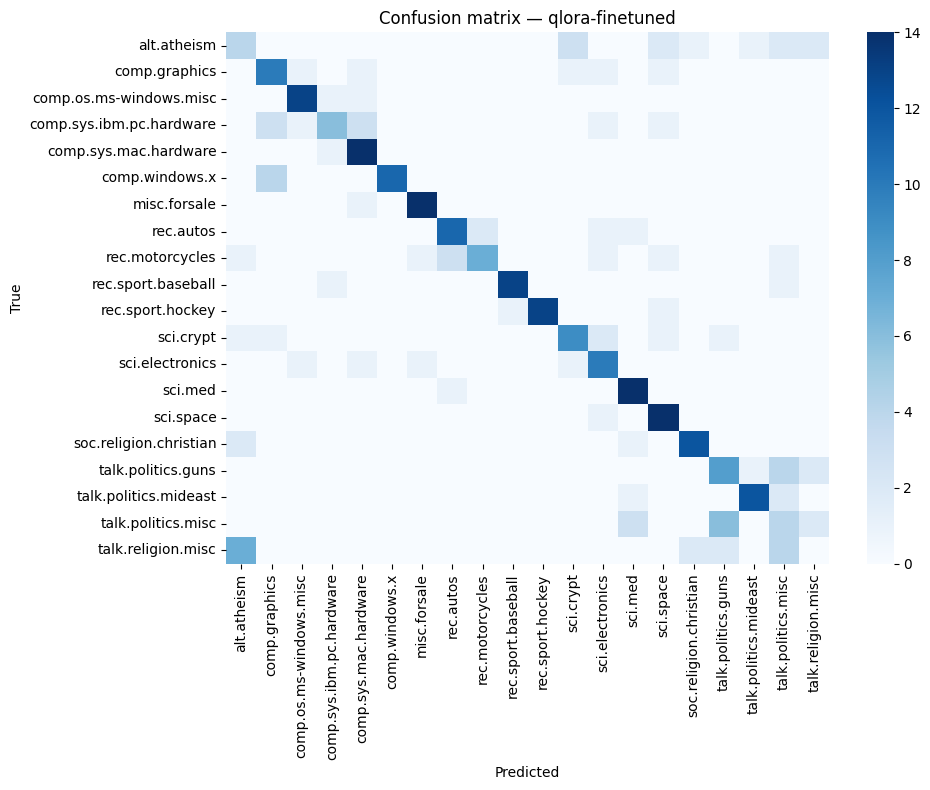

In [13]:
# Re-enable the cache for fast generation.
model.config.use_cache = True

def make_pipeline():
    return pipeline(
        task="text-generation",
        model=model, tokenizer=tokenizer,
        max_new_tokens=8,
        do_sample=False,
        return_full_text=False,
        pad_token_id=tokenizer.eos_token_id,
    )

def parse_label(generated: str) -> str:
    text = generated.strip().lower()
    for lbl in sorted(LABELS, key=len, reverse=True):
        if lbl.lower() in text: return lbl
    return "unknown"

pipe_ft = make_pipeline()
zero_shot_prompts = [build_zero_shot_prompt(t) for t in test_texts]
y_true = [ID2LABEL[i] for i in test_labels]

y_pred_ft = []
for p in tqdm(zero_shot_prompts, desc="predicting (fine-tuned)"):
    out = pipe_ft(p)
    y_pred_ft.append(parse_label(out[0]["generated_text"]))

# Metrics
yt = np.array([LABEL2ID[l]         for l in y_true])
yp = np.array([LABEL2ID.get(l, -1) for l in y_pred_ft])
acc_ft      = accuracy_score(yt, yp)
f1_macro_ft = f1_score(yt, yp, average="macro",
                       labels=list(range(NUM_CLASSES)), zero_division=0)
f1_weight_ft = f1_score(yt, yp, average="weighted",
                        labels=list(range(NUM_CLASSES)), zero_division=0)
cm_ft = confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES)))

print(f"\n=== QLoRA fine-tuned ===  acc={acc_ft:.4f}  macro-F1={f1_macro_ft:.4f}  weighted-F1={f1_weight_ft:.4f}")
print(classification_report(yt, yp, labels=list(range(NUM_CLASSES)),
                            target_names=LABELS, zero_division=0))

metrics_ft = {
    "accuracy":    acc_ft,
    "f1_macro":    f1_macro_ft,
    "f1_weighted": f1_weight_ft,
    "cm":          cm_ft.tolist(),
}

# Log to W&B
def plot_cm(cm, name):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(np.array(cm), xticklabels=LABELS, yticklabels=LABELS,
                cmap="Blues", annot=False, ax=ax)
    ax.set_title(f"Confusion matrix — {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

run = wandb.init(project=WANDB_PROJECT, name="qlora-finetuned-eval", reinit=True)
run.log({
    "accuracy":    acc_ft,
    "f1_macro":    f1_macro_ft,
    "f1_weighted": f1_weight_ft,
    "confusion_matrix": wandb.Image(plot_cm(cm_ft, "qlora-finetuned")),
})
run.finish()

## 14 · Comparison: QLoRA vs Task 4 baselines

Load `task4_metrics.json` (from your Task 4 notebook run) and build the
headline comparison table.

**If you don't have the JSON yet**, you can: (a) re-run Task 4 in this same
Colab session and the file will appear automatically, or (b) skip this cell
for now and run it later when you have the file.

In [14]:
if not TASK4_METRICS_PATH.exists():
    print(f"⚠ {TASK4_METRICS_PATH} not found — upload it or rerun Task 4.")
    summary_df = pd.DataFrame([
        {"method": "QLoRA fine-tuned",
         "accuracy": acc_ft, "f1_macro": f1_macro_ft, "f1_weighted": f1_weight_ft},
    ])
else:
    task4 = json.loads(TASK4_METRICS_PATH.read_text())
    rows = []
    for k in ["zero-shot", "few-shot-k1", "few-shot-k3", "few-shot-k5"]:
        if k in task4:
            rows.append({"method": k,
                         "accuracy":    task4[k]["accuracy"],
                         "f1_macro":    task4[k]["f1_macro"],
                         "f1_weighted": task4[k]["f1_weighted"]})
    rows.append({"method": "QLoRA fine-tuned",
                 "accuracy":    acc_ft,
                 "f1_macro":    f1_macro_ft,
                 "f1_weighted": f1_weight_ft})
    summary_df = pd.DataFrame(rows)

print(summary_df.to_string(index=False, float_format="%.4f"))
summary_df.to_csv("comparison_summary.csv", index=False)

          method  accuracy  f1_macro  f1_weighted
       zero-shot    0.0600    0.0921       0.0921
     few-shot-k1    0.4833    0.4928       0.4928
     few-shot-k3    0.4433    0.4387       0.4387
     few-shot-k5    0.4400    0.4194       0.4194
QLoRA fine-tuned    0.6633    0.6537       0.6537


### 14.1 Bar chart

Accuracy and macro-F1 side by side, one bar group per method. The fine-tuned
bar should sit clearly above all four prompted regimes — that's the headline
finding of the bonus task.

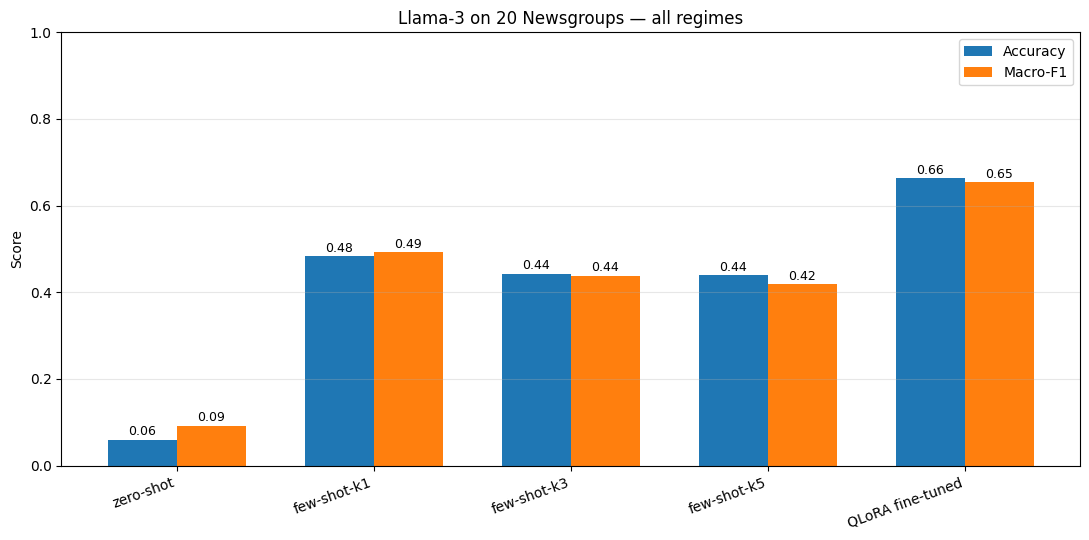

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df["accuracy"], width, label="Accuracy")
ax.bar(x + width/2, summary_df["f1_macro"], width, label="Macro-F1")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["method"], rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Llama-3 on 20 Newsgroups — all regimes")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (a, f) in enumerate(zip(summary_df["accuracy"], summary_df["f1_macro"])):
    ax.text(i - width/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + width/2, f + 0.01, f"{f:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("comparison_bar.png", dpi=150)
plt.show()

### 14.2 Side-by-side confusion matrices (all 5 regimes)

Reveals **where** the fine-tune helps and where it doesn't. Zero-shot
typically blurs the `comp.*` cluster; the fine-tuned model sharpens it.
Look at the diagonal density.

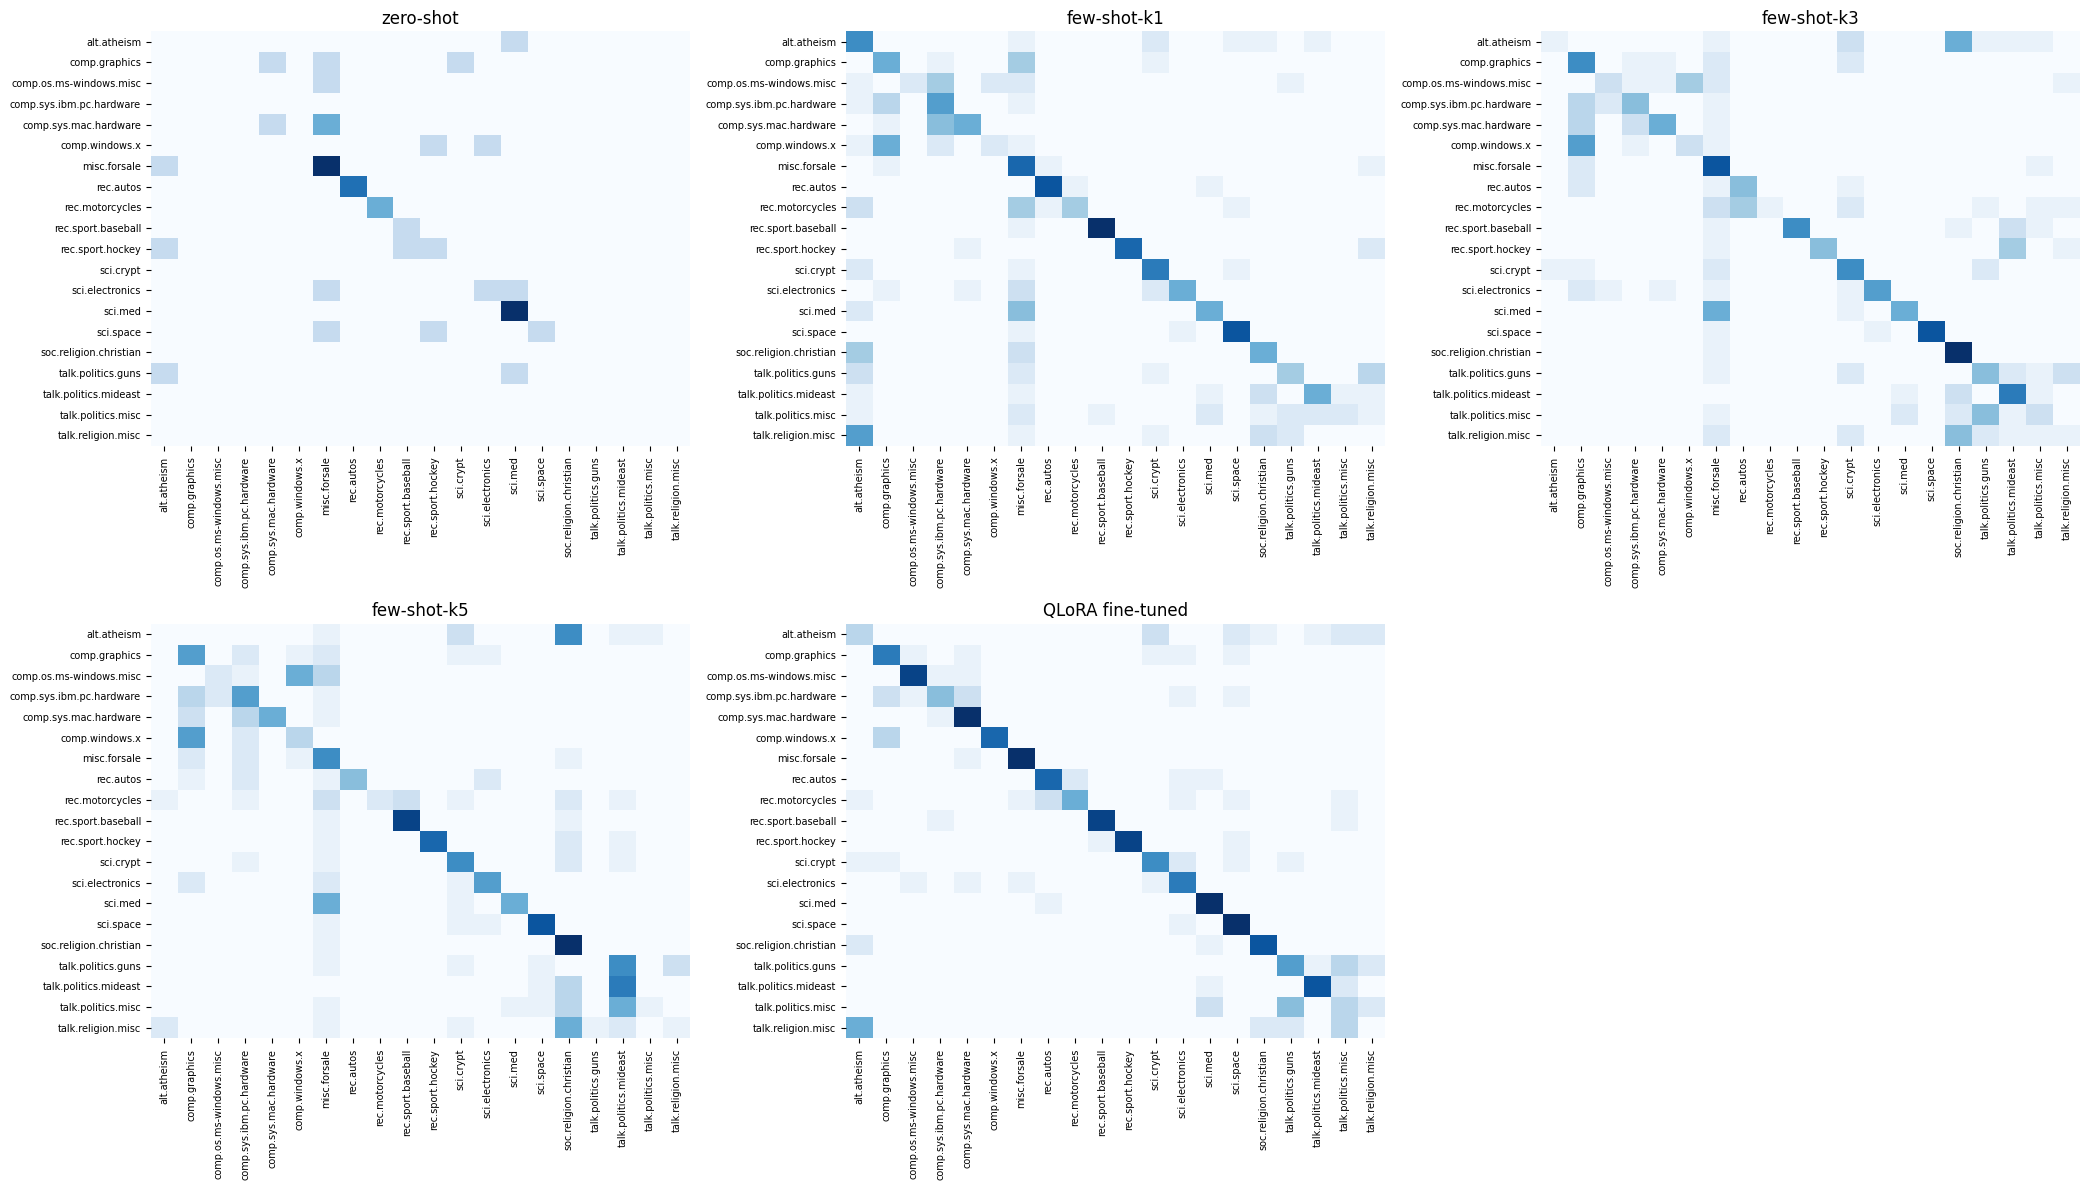

In [16]:
panels = []
if TASK4_METRICS_PATH.exists():
    task4 = json.loads(TASK4_METRICS_PATH.read_text())
    for k in ["zero-shot", "few-shot-k1", "few-shot-k3", "few-shot-k5"]:
        if k in task4:
            panels.append((k, np.array(task4[k]["cm"])))
panels.append(("QLoRA fine-tuned", cm_ft))

ncol = min(3, len(panels))
nrow = (len(panels) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(7 * ncol, 6 * nrow))
axes = np.atleast_2d(axes).ravel()
for ax, (name, cm) in zip(axes, panels):
    sns.heatmap(cm, xticklabels=LABELS, yticklabels=LABELS,
                cmap="Blues", annot=False, cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)
for ax in axes[len(panels):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=120)
plt.show()

### 14.3 Log summary table + charts to W&B

Creates a dedicated `summary` run in your W&B project containing the
comparison table and both figures. That's the run you screenshot for the
report.

In [17]:
final = wandb.init(project=WANDB_PROJECT, name="summary", reinit=True)
final.log({
    "summary_table":      wandb.Table(dataframe=summary_df),
    "comparison_bar":     wandb.Image("comparison_bar.png"),
    "confusion_matrices": wandb.Image("confusion_matrices_all.png"),
})
final.finish()

---

## 15 · Troubleshooting (skip unless something broke)

### `TypeError: SFTConfig.__init__() got an unexpected keyword argument`

The introspective `sft_kwargs` filter (section 11) should prevent this. If
you see it anyway, run:

```python
import inspect, trl
print(sorted(inspect.signature(trl.SFTConfig).parameters))
```

Then remove from `raw_sft_kwargs` anything not in the printed list.

### `NotImplementedError: _amp_foreach_non_finite_check_and_unscale_cuda for BFloat16`

You're on the fp16 path with bf16 adapters. Verify section 7 has
`bnb_4bit_compute_dtype=torch.bfloat16` AND section 11 has `fp16=False,
bf16=True`. Also confirm the defensive bf16-cast loop (end of section 11)
actually ran — print one trainable param's dtype: it must be `torch.bfloat16`.

### `ValueError: Some modules are dispatched on the CPU or the disk`

Out of GPU memory. Check `torch.cuda.mem_get_info()[0] / 1e9` — you need
≥ 6 GB free. If less, **Runtime → Disconnect and delete runtime**, reconnect,
run from the top. Don't use `"auto"` device map; `{"": 0}` (already set in
section 7) forces everything to GPU 0.

### Training loss doesn't decrease

Symptom of `prepare_model_for_kbit_training` not having been called, or the
trainable params being in the wrong dtype. Re-run sections 8 and 11.